### **객체 탐지** (Object Detection)

- Classification : 여러 물체에 대해 어떤 물체인지를 분류 하는 문제
- Localization : 물체가 어디에 있는지 박스를 통해 위치 정보를 나타내는 문제
- Object Detection : Classification + Localization

<img src = "https://blog.kakaocdn.net/dn/vykCu/btrGhxD6tI0/nixc1xh1kynI6O84km9us1/img.png">

### 학습 목표
- 동물객체를 탐지하는 모델을 만들어보기!
- 객체탐지에 필요한 기본 개념을 익혀보자

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/강의 자료들/2025/250813 LG DX 3기 강의자료

/content/drive/MyDrive/강의 자료들/2025/250813 LG DX 3기 강의자료


| 이탈리아어(Italian) | 영어(English) | 한국어(Korean) |
|:-------------------:|:------------:|:--------------:|
| cane               | dog          | 개             |
| cavallo            | horse        | 말             |
| elefante           | elephant     | 코끼리         |
| farfalla           | butterfly    | 나비           |
| gallina            | chicken      | 닭             |
| gatto              | cat          | 고양이         |
| mucca              | cow          | 소             |
| pecora             | sheep        | 양             |
| scoiattolo         | squirrel     | 다람쥐         |
| ragno              | spider       | 거미           |

In [4]:
!pwd

/content/drive/MyDrive/강의 자료들/2025/250813 LG DX 3기 강의자료


In [6]:
!curl -L "https://app.roboflow.com/ds/zYDcD6ybbi?key=Tm3eh5vqDd" > ./data/roboflow.zip
!unzip ./data/roboflow.zip -d ./data
!rm ./data/roboflow.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   896  100   896    0     0   3195      0 --:--:-- --:--:-- --:--:--  3200
100 25.5M  100 25.5M    0     0  33.2M      0 --:--:-- --:--:-- --:--:--  105M
Archive:  ./data/roboflow.zip
  inflating: ./data/README.dataset.txt  
  inflating: ./data/README.roboflow.txt  
  inflating: ./data/data.yaml        
   creating: ./data/test/
   creating: ./data/test/images/
 extracting: ./data/test/images/e133b50c20f01c22d2524518b7444f92e37fe5d404b0144390f8c078a0eabd_640_jpg.rf.c98e2fb6fb03be1baa7f1580b97e9785.jpg  
 extracting: ./data/test/images/e830b30a20f6053ed1584d05fb1d4e9fe777ead218ac104497f5c97faeebb5bb_640_png.rf.a6a03a9bfbe50a09fd00310ef52cecb0.jpg  
 extracting: ./data/test/images/e830b5082ff6013ed1584d05fb1d4e9fe777ead218ac104497f5c978a6ebb3bf_640_jpg.rf.72c17de174be34c88d99a8652c79a051.jpg  
 extracting: ./data/test/images/e83

- ⚠️ 주의사항 : 설정 파일(yaml) 확인 필수!

### 모델 학습

In [7]:
!pip -q install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.4 MB/s eta 0:00:00


In [8]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [9]:
# 사전학습 모델 로드
model = YOLO("./data/yolo11s.pt")

In [10]:
# 학습
results = model.train(
    data = "./data/data.yaml",
    epochs = 80,
    batch = 32,
    patience = 5,
    imgsz = 640,
    lr0 = 0.005 # 미세조정 → 10배에서 100배 가량 줄여서 설정
)

Ultralytics 8.3.183 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=./data/yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspective=0.0, plots=True, pose=12.0, pretrained=True,

Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics

 22                  -1  1   1511424  ultralytics.nn.modules.block.C3k2            [768, 512, 1, True]           
 23        [16, 19, 22]  1    820182  ultralytics.nn.modules.head.Detect           [2, [128, 256, 512]]          
YOLO11s summary: 181 layers, 9,428,566 parameters, 9,428,550 gradients, 21.6 GFLOPs

Transferred 493/499 items from pretrained weights
Freezing layer 'model.23.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed ✅
train: Fast image access ✅ (ping: 3.2±4.9 ms, read: 10.5±12.6 MB/s, size: 56.7 KB)


train: Scanning /content/drive/MyDrive/강의 자료들/2025/250813 LG DX 3기 강의자료/data/train/labels... 280 images, 0 backgrounds, 0 corrupt: 100%|██████████| 280/280 [00:02<00:00, 110.49it/s]


train: New cache created: /content/drive/MyDrive/강의 자료들/2025/250813 LG DX 3기 강의자료/data/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.8±0.2 ms, read: 20.2±11.8 MB/s, size: 58.7 KB)


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       6/80         8G      1.234      1.352      1.425        144        640: 100%|██████████| 9/9 [00:04<00:00,  1.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.64it/s]


                   all         80        120     0.0668      0.075     0.0144    0.00625
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 1, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

6 epochs completed in 0.021 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 19.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 19.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.183 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<00:00,  1.25it/s]


                   all         80        120      0.515      0.638      0.547      0.389
             butterfly         50         53      0.582      0.396      0.463      0.211
                 sheep         32         67      0.449      0.881      0.631      0.567
Speed: 0.3ms preprocess, 4.9ms inference, 0.0ms loss, 12.1ms postprocess per image
Results saved to runs/detect/train


### 모델 성능 지표
- Task 별로 모델의 성능을 평가할 수 있는 지표는 많다!

> 분류 vs 회귀
> - 분류 평가 지표 : 정확도, 재현율, 정밀도, f1, auc...
> - 회귀 평가 지표 : MSE, MAE, RMSE, R2...

### 분류 평가 지표
1. 정확도 (accuracy) : 전체 데이터 중 맞춘 개수에 대한 비율
2. 재현율 (recall) : 실제 양성인 것들을 얼마나 잘 찾아내는가에 대한 비율 (ex.높으면 높을수록 실제양성을 잘 예측한다!)
3. 정밀도 (precision) : 양성이라고 예측한 것 중에서 맞춘 것에 대한 비율 (ex.얼마나 정밀하게 잘 맞추는가?)

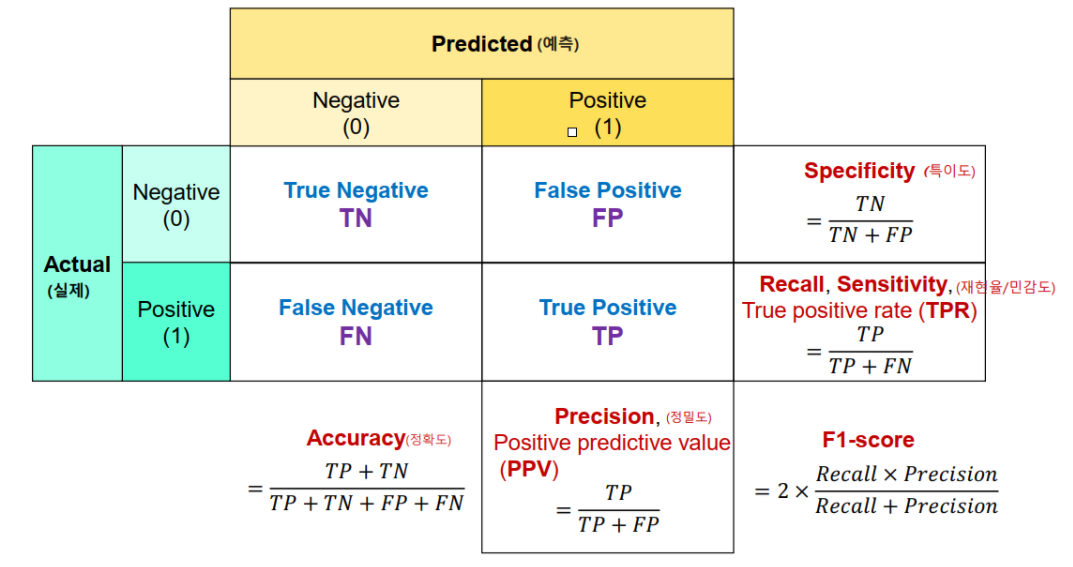

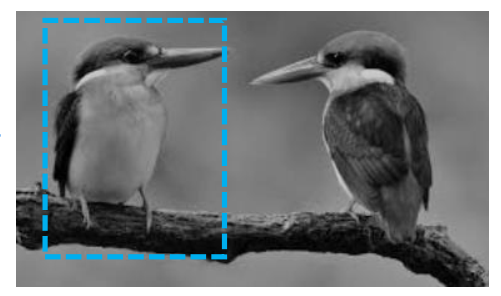

- 이미지 속에 새는 2마리
- 모델이 1마리만 찾아냄 (+ 정확하게 찾아냄!)
- precision = 1 / 1 = 100%
- recall = 1 / 2 = 50%

### 객체탐지에서 정탐 vs 오탐의 기준 - IoU
- ex.IoU = 0.5 설정 → 실제 바운딩 박스와 예측 바운딩 박스가 겹쳐진 정도가 50% 이상인 경우, 정탐이라고 판단!

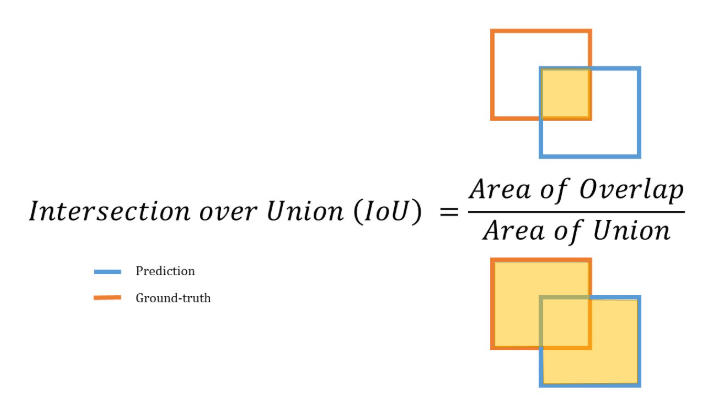

- 객체탐지에서 TP, FP, FN

> TN은 잘 사용되지 않음
> - TN : 배경으로 예측했는데 맞춘 거
> - 객체탐지에서는 그닥 중요하진 않음

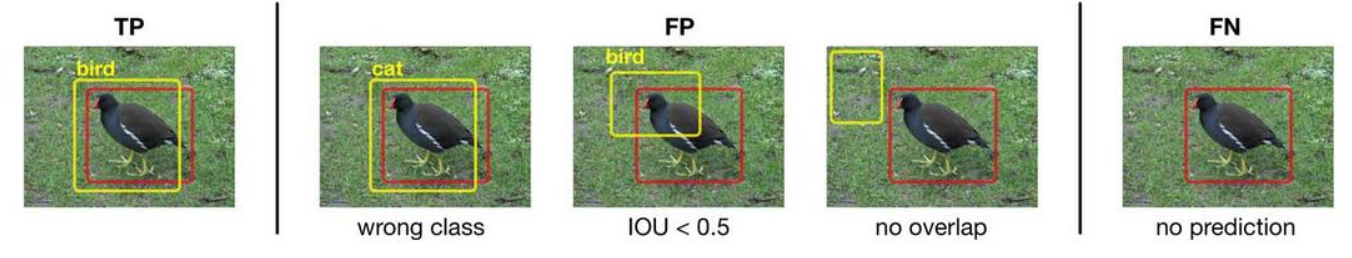

### Precision 와 Recall의 관계는 반비례!

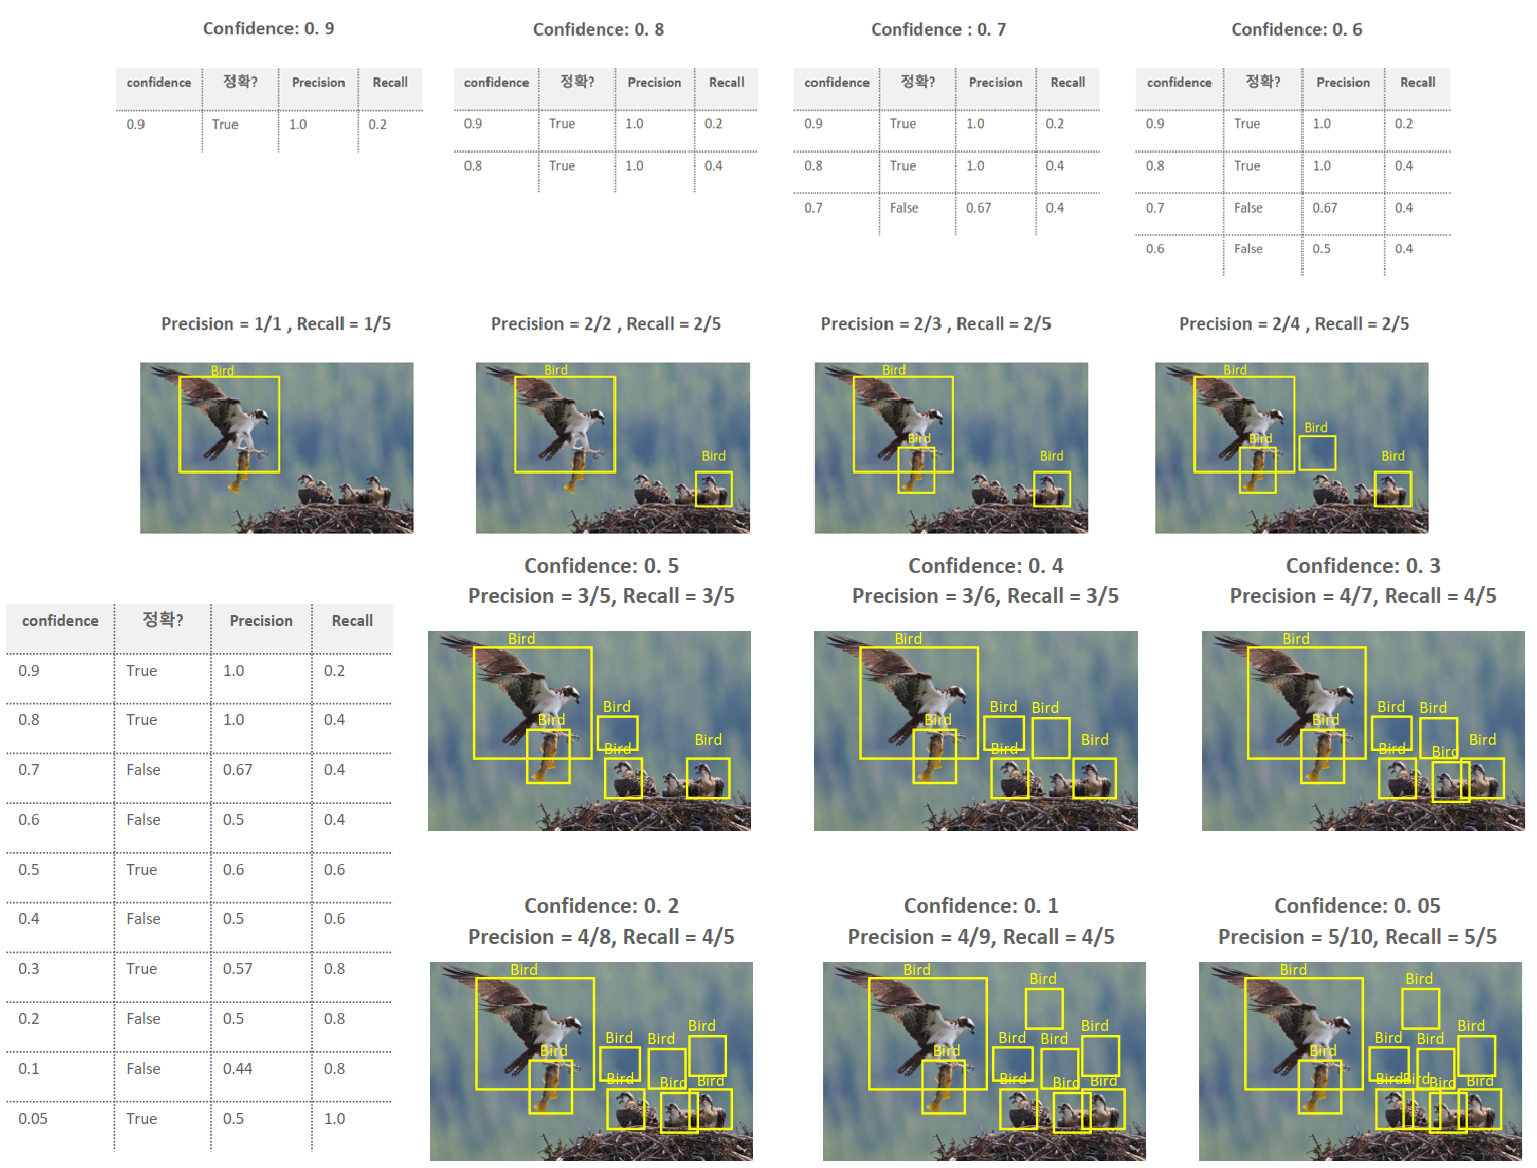

## PR Curve

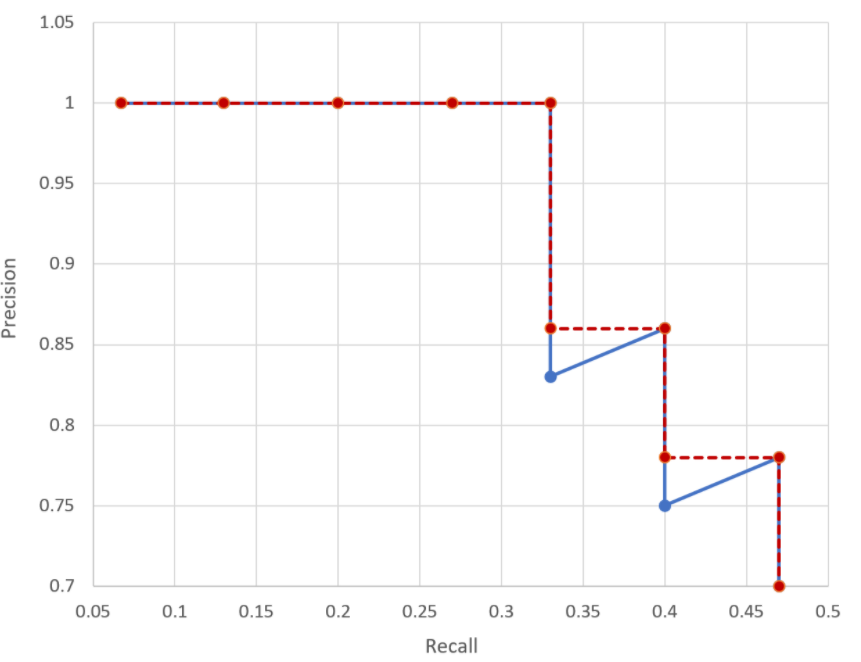

### 객체탐지 평가지표

> AP(Average Precision)
> - PR Curve 전체를 평가하기 위해, 계단형 곡선(빨간색 점선)으로 만든 뒤, 영역을 계산한 값(Area)
> - 0~1 사이의 값, 1에 가까울수록 높은 정밀도와 재현율을 함께 유지한다고 해석
> - 1ea 클래스 기준에서 계산 된 값

> mAP(mean AP)
> - 여러 클래스에 대한 AP값을 평균낸 값
> - 객체탐지모델의 종합 성능 평가지표로 자주 사용

### 개선방향
- 데이터 점검, 증강 : 라벨링 품질, 클래스 불균형(샘플링 기법 활용), 데이터 다양성 확보
- 학습 파라미터 최적화 : 학습률, Epochs, 배치사이즈, Early Stop 조건 재조정 등
- 모델 구조/크기 조정 : 다른 크기의 모델(s, n, m, l, x) 또는 백본 모델 변경 시도
- 후처리, 추가 튜닝 : 예측(추론) 모드에서 신뢰도 값 조절 등

In [11]:
# 학습시킨 모델 로드
best_model = YOLO("./runs/detect/train/weights/best.pt")

In [12]:
# 예측
results = best_model("./data/test/images/e832b70c2af0043ed1584d05fb1d4e9fe777ead218ac104497f5c97faeebb5bb_640_jpg.rf.184c2f750e7b8323800275fdd19cb9c9.jpg")


image 1/1 /content/drive/MyDrive/강의 자료들/2025/250813 LG DX 3기 강의자료/data/test/images/e832b70c2af0043ed1584d05fb1d4e9fe777ead218ac104497f5c97faeebb5bb_640_jpg.rf.184c2f750e7b8323800275fdd19cb9c9.jpg: 640x640 (no detections), 10.8ms
Speed: 7.6ms preprocess, 10.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


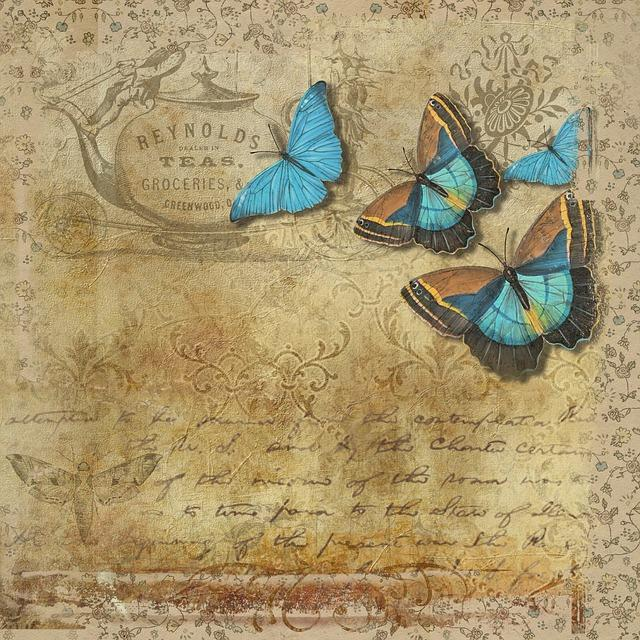

In [13]:
from PIL import Image
Image.open("./data/test/images/e832b70c2af0043ed1584d05fb1d4e9fe777ead218ac104497f5c97faeebb5bb_640_jpg.rf.184c2f750e7b8323800275fdd19cb9c9.jpg")

- 다음주에 OpenCV Ploting 가능! → OpenCV 기초, 영상 Model Ploting